In [ ]:
import gdown
import zipfile
import os
import shutil

def download_and_unzip_from_google_drive(file_id, output_dir, output_zip_name="downloaded.zip"):
    # 다운로드할 경로
    zip_file_path = os.path.join(output_dir, output_zip_name)

    # Google Drive 파일 다운로드
    gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_file_path, quiet=False)

    # ZIP 파일 압축 해제
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
        print(f"파일이 {output_dir}에 성공적으로 압축 해제되었습니다.")

    # ZIP 파일 삭제 (원한다면)
    os.remove(zip_file_path)
    print(f"ZIP 파일이 삭제되었습니다: {zip_file_path}")

def create_or_replace_directory(directory_path):
    # 디렉토리가 존재하는지 확인
    if os.path.exists(directory_path):
        # 디렉토리가 존재하면 삭제
        shutil.rmtree(directory_path)
        print(f"기존 디렉토리가 삭제되었습니다: {directory_path}")

    # 새로운 디렉토리 생성
    os.makedirs(directory_path)
    print(f"새로운 디렉토리가 생성되었습니다: {directory_path}")

# 사용 예시
file_id = "1uBY-JbXcPd-tikzFJcbwSR9_zEjYHHor"  # Google 드라이브 파일 ID
output_dir = "dataset"  # 압축을 풀 디렉토리 경로
create_or_replace_directory(output_dir)
download_and_unzip_from_google_drive(file_id, output_dir)



기존 디렉토리가 삭제되었습니다: dataset
새로운 디렉토리가 생성되었습니다: dataset


Downloading...
From (original): https://drive.google.com/uc?id=1uBY-JbXcPd-tikzFJcbwSR9_zEjYHHor
From (redirected): https://drive.google.com/uc?id=1uBY-JbXcPd-tikzFJcbwSR9_zEjYHHor&confirm=t&uuid=e3b4335e-b893-46c5-936f-00e4fc4eca1b
To: /content/dataset/downloaded.zip
100%|██████████| 634M/634M [00:02<00:00, 258MB/s]


파일이 dataset에 성공적으로 압축 해제되었습니다.
ZIP 파일이 삭제되었습니다: dataset/downloaded.zip


In [ ]:
original_dataset_dir = './dataset'
classes_list = os.listdir(original_dataset_dir)

base_dir = './splitted'
create_or_replace_directory(base_dir)

train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'val')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)

for cls in classes_list:
    os.mkdir(os.path.join(train_dir, cls))
    os.mkdir(os.path.join(validation_dir, cls))
    os.mkdir(os.path.join(test_dir, cls))


기존 디렉토리가 삭제되었습니다: ./splitted
새로운 디렉토리가 생성되었습니다: ./splitted


In [ ]:
import math

for cls in classes_list:
    path = os.path.join(original_dataset_dir, cls)
    fnames = os.listdir(path)

    train_size = math.floor(len(fnames) * 0.6)
    validation_size = math.floor(len(fnames) * 0.2)
    test_size = math.floor(len(fnames) * 0.2)

    train_fnames = fnames[:train_size]
    print("Train size(",cls,"): ", len(train_fnames))
    for fname in train_fnames:
        src = os.path.join(path, fname)
        dst = os.path.join(os.path.join(train_dir, cls), fname)
        shutil.copyfile(src, dst)

    validation_fnames = fnames[train_size:(validation_size + train_size)]
    print("Validation size(",cls,"): ", len(validation_fnames))
    for fname in validation_fnames:
        src = os.path.join(path, fname)
        dst = os.path.join(os.path.join(validation_dir, cls), fname)
        shutil.copyfile(src, dst)

    test_fnames = fnames[(train_size+validation_size):(validation_size + train_size +test_size)]

    print("Test size(",cls,"): ", len(test_fnames))
    for fname in test_fnames:
        src = os.path.join(path, fname)
        dst = os.path.join(os.path.join(test_dir, cls), fname)
        shutil.copyfile(src, dst)


Train size( Strawberry___Leaf_scorch ):  665
Validation size( Strawberry___Leaf_scorch ):  221
Test size( Strawberry___Leaf_scorch ):  221
Train size( Corn___Northern_Leaf_Blight ):  591
Validation size( Corn___Northern_Leaf_Blight ):  197
Test size( Corn___Northern_Leaf_Blight ):  197
Train size( Tomato___Early_blight ):  600
Validation size( Tomato___Early_blight ):  200
Test size( Tomato___Early_blight ):  200
Train size( Apple___healthy ):  987
Validation size( Apple___healthy ):  329
Test size( Apple___healthy ):  329
Train size( Cherry___healthy ):  512
Validation size( Cherry___healthy ):  170
Test size( Cherry___healthy ):  170
Train size( Strawberry___healthy ):  273
Validation size( Strawberry___healthy ):  91
Test size( Strawberry___healthy ):  91
Train size( Potato___Early_blight ):  600
Validation size( Potato___Early_blight ):  200
Test size( Potato___Early_blight ):  200
Train size( Tomato___Spider_mites Two-spotted_spider_mite ):  1005
Validation size( Tomato___Spider_m

In [ ]:
def get_device():
    import platform
    # 운영체제 확인
    os_name = platform.system()

    if os_name == "Darwin":  # MacOS
        # MPS (Metal Performance Shaders) 지원 확인
        if torch.backends.mps.is_available():
            print("Using MPS (Metal Performance Shaders) on Mac")
            return torch.device("mps")
        else:
            print("MPS not available, using CPU on Mac")
            return torch.device("cpu")

    elif os_name == "Linux" or os_name == "Windows":
        # CUDA 지원 확인
        if torch.cuda.is_available():
            print(f"Using CUDA on {os_name}")
            return torch.device("cuda")
        else:
            print(f"CUDA not available, using CPU on {os_name}")
            return torch.device("cpu")

    else:
        # 기타 운영체제에서는 기본적으로 CPU 사용
        print(f"Unsupported OS: {os_name}, using CPU by default")
        return torch.device("cpu")

# 장치 자동 선택
# device = get_device()


In [ ]:
import torch
import os

# USE_CUDA = torch.cuda.is_available()
# DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
DEVICE = torch.device(get_device())
BATCH_SIZE = 256
EPOCH = 30


Using CUDA on Linux


In [ ]:
import shutil
import os
from torchvision import datasets, transforms

# .ipynb_checkpoints 디렉토리 삭제 함수
def remove_ipynb_checkpoints(directory):
    for root, dirs, files in os.walk(directory):
        for dir_name in dirs:
            if dir_name == ".ipynb_checkpoints":
                shutil.rmtree(os.path.join(root, dir_name))
                print(f"Removed: {os.path.join(root, dir_name)}")

# .ipynb_checkpoints 디렉토리 삭제
remove_ipynb_checkpoints('./splitted/train')
remove_ipynb_checkpoints('./splitted/val')

# 전처리 및 데이터 로드
transform_base = transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor()])
train_dataset = datasets.ImageFolder(root='./splitted/train', transform=transform_base)
val_dataset = datasets.ImageFolder(root='./splitted/val', transform=transform_base)


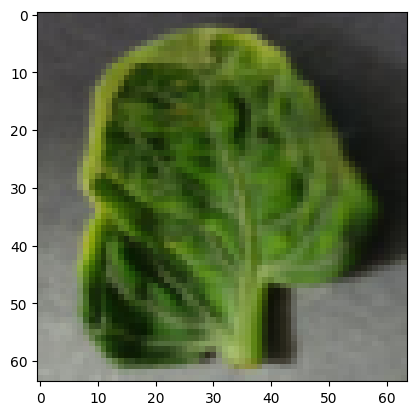

In [ ]:
from torch.utils.data import DataLoader

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

images , labels = next(iter(train_loader))

import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

F.to_pil_image(images[0]) # 이미지 확인
len(train_dataset.classes) # 클래스 값 확인
labels[0].item(),train_dataset.classes[labels[0].item()] # 레이블 값의 클래스 명을 확인
plt.imshow(F.to_pil_image(images[0]))


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Net(nn.Module):

    def __init__(self):

        super(Net, self).__init__()
        # 이미지채널 3, 필터적용개수 32, 필터사이즈 3, 이미지의 입력은(3,64,64)
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)

        self.fc1 = nn.Linear(4096, 512)
        self.fc2 = nn.Linear(512, 33)

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = x.view(-1, 4096) # 64*8*8
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)

model_base = Net().to(DEVICE)
optimizer = optim.Adam(model_base.parameters(), lr=0.001)


In [ ]:
def train(model, train_loader, optimizer):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)

            test_loss += F.cross_entropy(output,target, reduction='sum').item()


            pred = output.max(1, keepdim=True)[1] # 각 행별로 가장 큰값의 인덱스 값을 리턴
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, test_accuracy



In [ ]:
import torch

# 예: 배치 크기 3, 클래스 수 4
output = torch.tensor([
    [0.2, 0.1, 0.6, 0.1],  # → 클래스 2 (0.6)
    [0.3, 0.4, 0.2, 0.1],  # → 클래스 1 (0.4)
    [0.05, 0.2, 0.3, 0.45] # → 클래스 3 (0.45)
])

pred = output.max(1, keepdim=True)[1]
print(pred)


tensor([[2],
        [1],
        [3]])


In [ ]:
import time
import copy

def train_baseline(model ,train_loader, val_loader, optimizer, num_epochs = 30):
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        since = time.time()
        train(model, train_loader, optimizer)
        train_loss, train_acc = evaluate(model, train_loader)
        val_loss, val_acc = evaluate(model, val_loader)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('-------------- epoch {} ----------------'.format(epoch))
        print('train Loss: {:.4f}, Accuracy: {:.2f}%'.format(train_loss, train_acc))
        print('val Loss: {:.4f}, Accuracy: {:.2f}%'.format(val_loss, val_acc))
        print('Completed in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    model.load_state_dict(best_model_wts)
    return model


base = train_baseline(model_base, train_loader, val_loader, optimizer, EPOCH)


-------------- epoch 1 ----------------
train Loss: 1.5644, Accuracy: 54.62%
val Loss: 1.5907, Accuracy: 53.70%
Completed in 1m 18s
-------------- epoch 2 ----------------
train Loss: 0.8950, Accuracy: 73.46%
val Loss: 0.9298, Accuracy: 72.36%
Completed in 1m 23s
-------------- epoch 3 ----------------
train Loss: 0.6738, Accuracy: 79.43%
val Loss: 0.7175, Accuracy: 77.94%
Completed in 1m 16s
-------------- epoch 4 ----------------
train Loss: 0.5204, Accuracy: 83.32%
val Loss: 0.5744, Accuracy: 81.62%
Completed in 1m 16s
-------------- epoch 5 ----------------
train Loss: 0.4558, Accuracy: 85.71%
val Loss: 0.5195, Accuracy: 83.06%
Completed in 1m 14s
-------------- epoch 6 ----------------
train Loss: 0.3555, Accuracy: 89.33%
val Loss: 0.4334, Accuracy: 86.21%
Completed in 1m 15s
-------------- epoch 7 ----------------
train Loss: 0.3423, Accuracy: 89.28%
val Loss: 0.4185, Accuracy: 86.43%
Completed in 1m 15s
-------------- epoch 8 ----------------
train Loss: 0.2764, Accuracy: 91.63%

In [ ]:
data_transforms = {
    'train': transforms.Compose([transforms.Resize([64,64]),
        transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
        transforms.RandomCrop(52), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) ]),

    'val': transforms.Compose([transforms.Resize([64,64]),
        transforms.RandomCrop(52), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) ])
}


In [ ]:
data_dir = './splitted'
image_datasets = {x: datasets.ImageFolder(root=os.path.join(data_dir, x), transform=data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes


In [ ]:
from torchvision import models

resnet = models.resnet50(pretrained=True)
# print(resnet) 으로 구성 레이어를 확인할 수 있다.
#  (fc): Linear(in_features=2048, out_features=1000, bias=True)
# 마지막 레이어인 분류기 쪽에 출력값을 33으로 조정한다.
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 33)

resnet = resnet.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.001)

from torch.optim import lr_scheduler

# 7 에폭마다 학습률에 0.1을 곱하여 학습률을 줄여나간다.
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


In [ ]:
ct = 0
for child in resnet.children():
    ct += 1
    print(ct)
    print(child)
    print('---------------------------------')
    if ct < 9:
        for param in child.parameters():
            param.requires_grad = False


1
Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
---------------------------------
2
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
---------------------------------
3
ReLU(inplace=True)
---------------------------------
4
MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
---------------------------------
5
Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequent

In [ ]:
def train_resnet(model, criterion, optimizer, scheduler, num_epochs=25):

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('-------------- epoch {} ----------------'.format(epoch+1))
        since = time.time()
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0


            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss/dataset_sizes[phase]
            # epoch_acc = running_corrects.double()/dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]  # .double() 대신 .float()로 수정

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))


            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('Completed in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)

    return model


In [ ]:
model_resnet50 = train_resnet(resnet, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=EPOCH)


-------------- epoch 1 ----------------
train Loss: 1.6889 Acc: 0.5548
val Loss: 1.1600 Acc: 0.6859
Completed in 1m 1s
-------------- epoch 2 ----------------
train Loss: 1.0597 Acc: 0.7010
val Loss: 1.0076 Acc: 0.6995
Completed in 1m 0s
-------------- epoch 3 ----------------
train Loss: 0.9378 Acc: 0.7273
val Loss: 0.9047 Acc: 0.7349
Completed in 0m 59s
-------------- epoch 4 ----------------
train Loss: 0.8675 Acc: 0.7432
val Loss: 0.8479 Acc: 0.7482
Completed in 1m 1s
-------------- epoch 5 ----------------
train Loss: 0.8179 Acc: 0.7546
val Loss: 0.8128 Acc: 0.7594
Completed in 1m 1s
-------------- epoch 6 ----------------
train Loss: 0.7937 Acc: 0.7593
val Loss: 0.7934 Acc: 0.7638
Completed in 1m 1s
-------------- epoch 7 ----------------
train Loss: 0.7626 Acc: 0.7723
val Loss: 0.7450 Acc: 0.7769
Completed in 1m 1s
-------------- epoch 8 ----------------
train Loss: 0.7255 Acc: 0.7814
val Loss: 0.7468 Acc: 0.7776
Completed in 1m 1s
-------------- epoch 9 ----------------
train L

In [ ]:
torch.save(model_resnet50, 'resnet50.pt')
